# The Three Elemental Confounds: Forks, Pipes, and Colliders

## Learning Objectives

By the end of this notebook you will be able to:

1. Draw and recognise the three elemental causal structures — **fork**, **pipe**, and **collider** — and explain why they are the building blocks of all causal reasoning.
2. Explain how a **fork** (common cause) creates a spurious association between two variables, and demonstrate that conditioning on the common cause removes it.
3. Explain how a **pipe** (mediator) transmits a causal effect, and why conditioning on the mediator blocks the total causal path.
4. Explain the **collider** structure and the counter-intuitive result that conditioning on a collider *creates* a spurious association between otherwise independent variables.
5. Simulate data from each structure, verify the conditional independence relationships numerically, and visualise them with scatter plots and partial correlations.
6. Recognise **Simpson's Paradox** as a consequence of confounding (fork structure) and demonstrate it with a simulation.
7. State the correct conditioning strategy for each structure and explain why "always control for everything" is wrong.

## Prerequisites

- [Module 01 — Probability basics, conditional probability](../01_probability_basics/03_conditional_probability.ipynb)
- [Module 06 — Linear regression](../06_linear_models/01_simple_linear_regression.ipynb)
- Basic familiarity with DAGs (directed acyclic graphs)

In [6]:
import sys, os, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    os.system(
        "sudo apt-get update -qq && sudo apt-get install -y -qq "
        "libcairo2-dev libpango1.0-dev && pip install -q manim networkx ipython==8.21.0"
    )

_miktex_bin = Path.home() / "AppData/Local/Programs/MiKTeX/miktex/bin/x64"
if _miktex_bin.exists() and str(_miktex_bin) not in os.environ.get("PATH", ""):
    os.environ["PATH"] += os.pathsep + str(_miktex_bin)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import networkx as nx
from scipy import stats
from sklearn.linear_model import LogisticRegression

sys.path.insert(0, os.path.abspath("../../src"))
from amstats.plotting import (
    apply_style,
    SALMON,
    GOLD,
    EMERALD,
    CYAN,
    PERIWINKLE,
    ORCHID,
)

apply_style()


class Cfg:
    root = Path("../../").resolve()
    gif_dir = root / "media" / "gifs"
    has_latex: bool = (
        shutil.which("latex") is not None or shutil.which("pdflatex") is not None
    )

    def __init__(self):
        self.gif_dir.mkdir(parents=True, exist_ok=True)

    def apply_manim_config(self):
        from manim import config as mcfg

        mcfg.format = "gif"

    def math_text(self, expr, **kwargs):
        from manim import MathTex, Text

        if self.has_latex:
            return MathTex(expr, **kwargs)
        return Text(expr, **kwargs)

    def save_gifs(self, clean=True):
        local_media = Path("media")
        found = list(local_media.rglob("*.gif")) if local_media.exists() else []
        if not found:
            print("  No new GIFs to save.")
            return
        for gif in found:
            dest = self.gif_dir / gif.name
            shutil.copy2(gif, dest)
            print(f"  \u2713 media/gifs/{gif.name}")
        if clean:
            for sub in ("videos", "images", "Tex"):
                d = local_media / sub
                if d.exists():
                    shutil.rmtree(d, ignore_errors=True)
            print("  Cleaned up local temp render files (kept media/jupyter/).")


cfg = Cfg()
rng = np.random.default_rng(42)
print(f"LaTeX available: {cfg.has_latex}")

LaTeX available: True


---

## 1. The Three Elemental Structures

Every DAG — no matter how large or tangled — is built from exactly three elemental structures involving three variables $X$, $Y$, and $Z$.  These structures determine **which associations exist** in the data and **how conditioning changes them**.  Understanding these three patterns is the single most important step in causal reasoning.

| Structure               | DAG                             | Association $X$–$Y$   | Condition on $Z$ | Result                 |
|-------------------------|---------------------------------|-----------------------|------------------|------------------------|
| **Fork** (common cause) | $X \leftarrow Z \rightarrow Y$  | Correlated (spurious) | Blocks the path  | Association disappears |
| **Pipe** (mediator)     | $X \rightarrow Z \rightarrow Y$ | Correlated (causal)   | Blocks the path  | Association disappears |
| **Collider**            | $X \rightarrow Z \leftarrow Y$  | Independent           | Opens the path   | Association *created*  |

The first two are intuitive — conditioning removes an association.  The third is the dangerous one: conditioning on a collider **creates** a spurious association that did not exist before.  This is why the naive advice "control for everything" is wrong.

Let us examine each in detail.

### Helper: Drawing DAGs with NetworkX

We will use NetworkX to draw small DAGs throughout this notebook.  The helper below produces consistent, clean DAG plots.

In [7]:
def draw_dag(
    edges,
    pos,
    title="",
    ax=None,
    node_color=PERIWINKLE,
    conditioned=None,
    cond_color=SALMON,
):
    """Draw a small DAG with optional conditioned (boxed) nodes.

    Parameters
    ----------
    edges : list of (str, str)
    pos : dict  node -> (x, y)
    conditioned : set of node names to draw as conditioned (square box)
    """
    if ax is None:
        _, ax = plt.subplots(figsize=(4, 3))
    conditioned = conditioned or set()

    G = nx.DiGraph(edges)

    # Node colours
    colors = [cond_color if n in conditioned else node_color for n in G.nodes()]
    shapes_round = [n for n in G.nodes() if n not in conditioned]
    shapes_square = [n for n in G.nodes() if n in conditioned]

    # Draw round nodes
    if shapes_round:
        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=shapes_round,
            ax=ax,
            node_color=[node_color] * len(shapes_round),
            node_size=1200,
            node_shape="o",
            edgecolors="white",
            linewidths=2,
        )
    # Draw square (conditioned) nodes
    if shapes_square:
        nx.draw_networkx_nodes(
            G,
            pos,
            nodelist=shapes_square,
            ax=ax,
            node_color=[cond_color] * len(shapes_square),
            node_size=1200,
            node_shape="s",
            edgecolors="white",
            linewidths=2,
        )

    nx.draw_networkx_labels(
        G, pos, ax=ax, font_size=16, font_color="white", font_weight="bold"
    )
    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        edge_color="#888888",
        width=2.5,
        arrows=True,
        arrowsize=20,
        connectionstyle="arc3,rad=0.05",
    )

    ax.set_title(title, fontsize=13, pad=10)
    ax.axis("off")

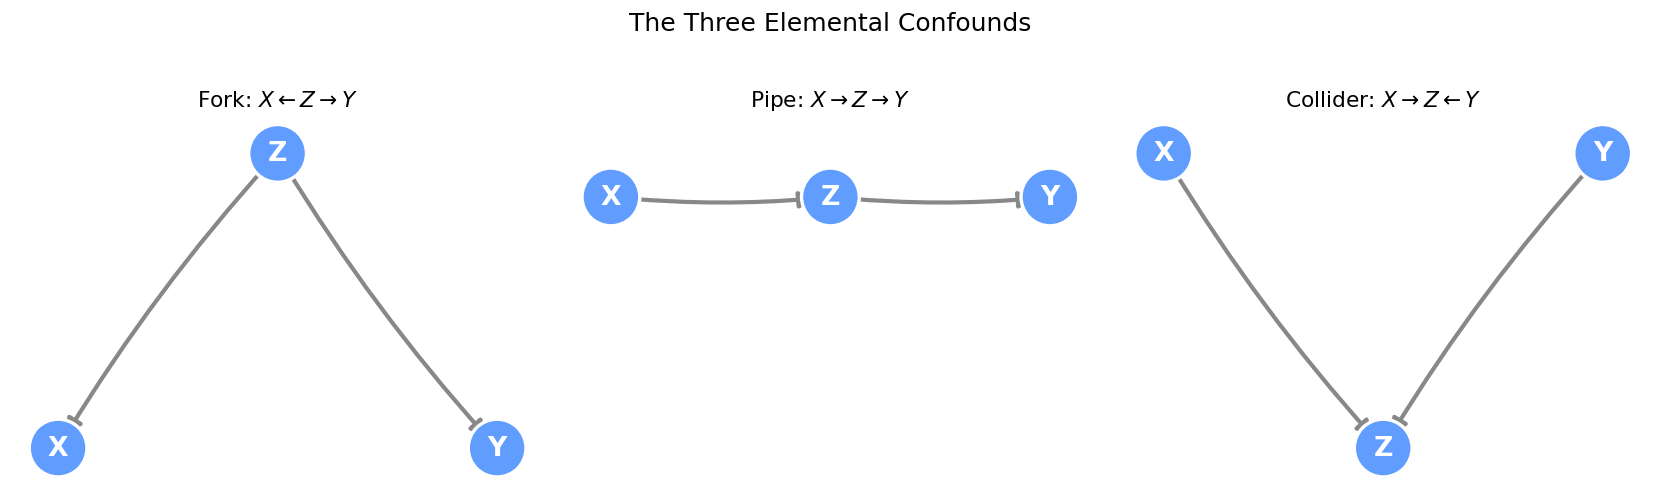

In [8]:
# Draw all three elemental structures side by side
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Fork: X <- Z -> Y
draw_dag(
    [("Z", "X"), ("Z", "Y")],
    {"X": (0, 0), "Z": (1, 1), "Y": (2, 0)},
    title="Fork: $X \\leftarrow Z \\rightarrow Y$",
    ax=axes[0],
)

# Pipe: X -> Z -> Y
draw_dag(
    [("X", "Z"), ("Z", "Y")],
    {"X": (0, 0), "Z": (1, 0), "Y": (2, 0)},
    title="Pipe: $X \\rightarrow Z \\rightarrow Y$",
    ax=axes[1],
)

# Collider: X -> Z <- Y
draw_dag(
    [("X", "Z"), ("Y", "Z")],
    {"X": (0, 1), "Z": (1, 0), "Y": (2, 1)},
    title="Collider: $X \\rightarrow Z \\leftarrow Y$",
    ax=axes[2],
)

plt.suptitle("The Three Elemental Confounds", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

---

## 2. The Fork (Common Cause)

### Definition

A **fork** is the structure $X \leftarrow Z \rightarrow Y$, where $Z$ is a **common cause** of both $X$ and $Y$.  The variable $Z$ is sometimes called a **confounder**.

### Why it creates a spurious association

Because $Z$ influences both $X$ and $Y$, learning about $X$ tells you something about $Z$ (since $Z$ caused $X$), which in turn tells you something about $Y$ (since $Z$ also caused $Y$).  This creates a statistical association between $X$ and $Y$ even though **neither causes the other**.

Formally, the path $X \leftarrow Z \rightarrow Y$ is an **open path** that transmits association from $X$ to $Y$ through the common cause $Z$.  This is a **non-causal path** — the association it creates is entirely spurious.

### Conditioning on $Z$ blocks the path

If we **condition on** (stratify by, adjust for, hold constant) $Z$, the path is **blocked**.  Within any stratum where $Z$ is held constant, $X$ and $Y$ are independent.  This is the formal statement:

$$X \perp\!\!\!\perp Y \mid Z \qquad \text{(conditional independence in a fork)}$$

Intuitively: if you already know $Z$, then learning $X$ tells you nothing new about $Y$, because $X$ and $Y$ are connected *only* through $Z$.

### Classic example: Ice cream and drowning

- $X$ = ice cream sales
- $Y$ = drowning deaths  
- $Z$ = temperature

Hot weather causes both more ice cream sales and more swimming (hence more drownings).  Observationally, ice cream sales and drowning deaths are positively correlated.  But ice cream does not cause drowning.  If we control for temperature, the association vanishes.

### Simulation

Let us generate data from a fork structure and verify the conditional independence claim.

**Data-generating process:**

$$Z \sim \mathcal{N}(0, 1)$$
$$X = 0.9\,Z + \varepsilon_X, \qquad \varepsilon_X \sim \mathcal{N}(0, 0.3^2)$$
$$Y = 0.7\,Z + \varepsilon_Y, \qquad \varepsilon_Y \sim \mathcal{N}(0, 0.3^2)$$

Note: $X$ and $Y$ share no direct causal link — they are connected **only** through $Z$.

In [9]:
# ── Fork simulation ──
n = 2000

Z_fork = rng.normal(0, 1, n)
X_fork = 0.9 * Z_fork + rng.normal(0, 0.3, n)
Y_fork = 0.7 * Z_fork + rng.normal(0, 0.3, n)

# Marginal correlation (should be nonzero — spurious!)
r_marginal, p_marginal = stats.pearsonr(X_fork, Y_fork)
print(f"Marginal correlation r(X, Y) = {r_marginal:.4f}  (p = {p_marginal:.2e})")
print("X and Y appear strongly correlated — but this is entirely spurious!")

Marginal correlation r(X, Y) = 0.8768  (p = 0.00e+00)
X and Y appear strongly correlated — but this is entirely spurious!


In [10]:
def partial_correlation(x, y, z):
    """Compute the partial correlation of x and y given z.

    Residualise both x and y on z via OLS, then correlate the residuals.
    This is numerically equivalent to the textbook formula.
    """
    # Vectorised OLS residuals
    z_dm = z - z.mean()
    ss_z = z_dm @ z_dm
    res_x = x - x.mean() - (z_dm @ (x - x.mean())) / ss_z * z_dm
    res_y = y - y.mean() - (z_dm @ (y - y.mean())) / ss_z * z_dm
    r, p = stats.pearsonr(res_x, res_y)
    return r, p, res_x, res_y


r_partial, p_partial, res_x_fork, res_y_fork = partial_correlation(
    X_fork, Y_fork, Z_fork
)
print(f"Partial correlation r(X, Y | Z) = {r_partial:.4f}  (p = {p_partial:.3f})")
print("After conditioning on Z, the association between X and Y vanishes.")

Partial correlation r(X, Y | Z) = 0.0444  (p = 0.047)
After conditioning on Z, the association between X and Y vanishes.


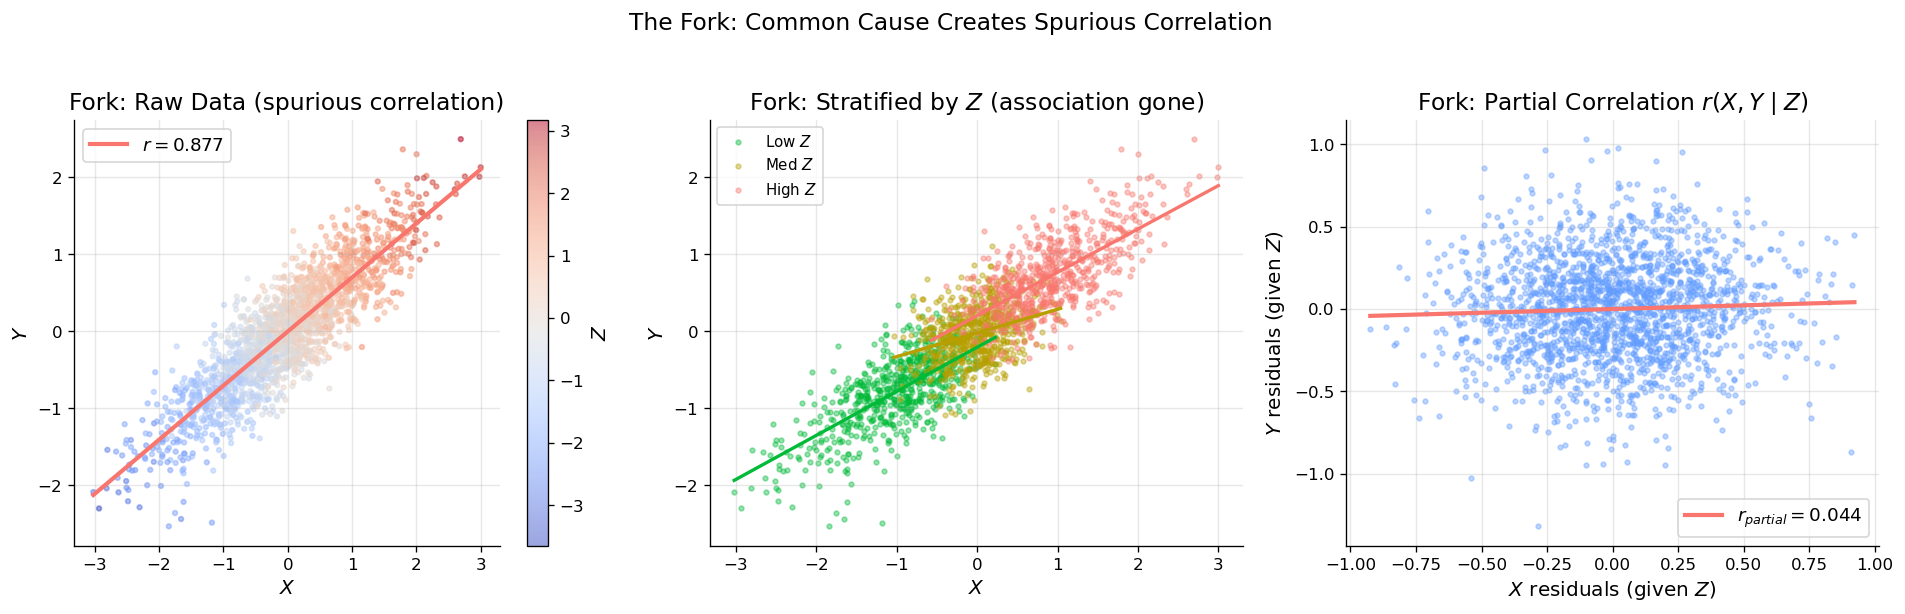

In [11]:
# ── Fork: scatter plots — raw vs. conditioned ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: raw scatter X vs Y (coloured by Z)
sc = axes[0].scatter(X_fork, Y_fork, c=Z_fork, cmap="coolwarm", s=8, alpha=0.5)
plt.colorbar(sc, ax=axes[0], label="$Z$")
# Regression line
m, b = np.polyfit(X_fork, Y_fork, 1)
x_line = np.linspace(X_fork.min(), X_fork.max(), 100)
axes[0].plot(
    x_line, m * x_line + b, color=SALMON, lw=2.5, label=f"$r = {r_marginal:.3f}$"
)
axes[0].set_xlabel("$X$")
axes[0].set_ylabel("$Y$")
axes[0].set_title("Fork: Raw Data (spurious correlation)")
axes[0].legend()

# Middle: stratified by Z (low / medium / high)
z_terciles = np.percentile(Z_fork, [33, 67])
labels_z = ["Low $Z$", "Med $Z$", "High $Z$"]
colours_z = [EMERALD, GOLD, SALMON]
masks = [
    Z_fork < z_terciles[0],
    (Z_fork >= z_terciles[0]) & (Z_fork < z_terciles[1]),
    Z_fork >= z_terciles[1],
]
for mask, lbl, col in zip(masks, labels_z, colours_z):
    axes[1].scatter(X_fork[mask], Y_fork[mask], s=8, alpha=0.4, color=col, label=lbl)
    if mask.sum() > 2:
        m_s, b_s = np.polyfit(X_fork[mask], Y_fork[mask], 1)
        xr = np.linspace(X_fork[mask].min(), X_fork[mask].max(), 50)
        axes[1].plot(xr, m_s * xr + b_s, color=col, lw=2)
axes[1].set_xlabel("$X$")
axes[1].set_ylabel("$Y$")
axes[1].set_title("Fork: Stratified by $Z$ (association gone)")
axes[1].legend(fontsize=9)

# Right: residuals after conditioning on Z
axes[2].scatter(res_x_fork, res_y_fork, s=8, alpha=0.4, color=PERIWINKLE)
m_r, b_r = np.polyfit(res_x_fork, res_y_fork, 1)
xr2 = np.linspace(res_x_fork.min(), res_x_fork.max(), 100)
axes[2].plot(
    xr2,
    m_r * xr2 + b_r,
    color=SALMON,
    lw=2.5,
    label=f"$r_{{partial}} = {r_partial:.3f}$",
)
axes[2].set_xlabel("$X$ residuals (given $Z$)")
axes[2].set_ylabel("$Y$ residuals (given $Z$)")
axes[2].set_title("Fork: Partial Correlation $r(X,Y \\mid Z)$")
axes[2].legend()

plt.suptitle("The Fork: Common Cause Creates Spurious Correlation", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Left panel:** The raw scatter shows a strong positive correlation between $X$ and $Y$.  The colour gradient (blue = low $Z$, red = high $Z$) reveals the source: points with high $Z$ have both high $X$ and high $Y$.  The common cause $Z$ drives both.

**Middle panel:** When we stratify by $Z$ (split into terciles), the within-group regression lines are nearly flat.  Inside each stratum, $X$ and $Y$ are approximately independent.

**Right panel:** The partial correlation (residuals after regressing out $Z$) is approximately zero.  The spurious association has been completely removed.

**The lesson:** To estimate the causal effect of $X$ on $Y$, we must **control for confounders** (common causes).  In the fork structure, failing to control for $Z$ leads to a spurious association.

---

## 3. The Pipe (Mediator)

### Definition

A **pipe** is the structure $X \rightarrow Z \rightarrow Y$, where $Z$ is a **mediator** that lies on the causal path from $X$ to $Y$.  The effect of $X$ on $Y$ is transmitted *through* $Z$.

### Why $X$ and $Y$ are associated

The path $X \rightarrow Z \rightarrow Y$ is an open causal path.  $X$ causes $Z$, and $Z$ causes $Y$, so $X$ and $Y$ are associated — and this association is **genuinely causal**.

### Conditioning on $Z$ blocks the path

If we condition on $Z$, the path from $X$ to $Y$ is blocked:

$$X \perp\!\!\!\perp Y \mid Z \qquad \text{(conditional independence in a pipe)}$$

Intuitively: if you already know the value of the mediator $Z$, then knowing $X$ adds no information about $Y$, because $X$ affects $Y$ **only** through $Z$.

### The critical distinction: when to condition and when not to

- **Total effect** of $X$ on $Y$: Do **not** condition on $Z$.  The total effect flows through the mediator; blocking it removes the very effect you are trying to measure.
- **Direct effect** of $X$ on $Y$ (bypassing $Z$): Condition on $Z$.  If there is an additional direct arrow $X \rightarrow Y$, then the association that remains after conditioning on $Z$ is the direct effect.

In the pure pipe ($X \rightarrow Z \rightarrow Y$ with no direct $X \rightarrow Y$ arrow), the total effect equals the indirect effect, and the direct effect is zero.  Conditioning on $Z$ would incorrectly make it look like $X$ has no effect on $Y$ at all.

### Classic example: Education, Income, and Health

- $X$ = years of education
- $Z$ = income
- $Y$ = health outcomes

Education increases income, and income provides access to better healthcare, nutrition, and living conditions.  If we control for income, the apparent effect of education on health shrinks dramatically — not because education does not matter, but because we have blocked the causal channel through which it operates.

### Simulation

**Data-generating process:**

$$X \sim \mathcal{N}(0, 1)$$
$$Z = 0.8\,X + \varepsilon_Z, \qquad \varepsilon_Z \sim \mathcal{N}(0, 0.3^2)$$
$$Y = 0.6\,Z + \varepsilon_Y, \qquad \varepsilon_Y \sim \mathcal{N}(0, 0.3^2)$$

The total causal effect of $X$ on $Y$ is $0.8 \times 0.6 = 0.48$.  There is no direct $X \rightarrow Y$ arrow.

In [12]:
# ── Pipe simulation ──
X_pipe = rng.normal(0, 1, n)
Z_pipe = 0.8 * X_pipe + rng.normal(0, 0.3, n)
Y_pipe = 0.6 * Z_pipe + rng.normal(0, 0.3, n)

# Marginal correlation (should be nonzero — causal!)
r_marg_pipe, p_marg_pipe = stats.pearsonr(X_pipe, Y_pipe)
print(f"Marginal correlation r(X, Y) = {r_marg_pipe:.4f}  (p = {p_marg_pipe:.2e})")
print(f"Expected total effect: 0.8 * 0.6 = 0.48")

# Partial correlation conditioning on Z (should be ~0)
r_part_pipe, p_part_pipe, res_x_pipe, res_y_pipe = partial_correlation(
    X_pipe, Y_pipe, Z_pipe
)
print(f"\nPartial correlation r(X, Y | Z) = {r_part_pipe:.4f}  (p = {p_part_pipe:.3f})")
print("Conditioning on Z blocks the causal path — the association vanishes!")
print("If your goal is the TOTAL effect of X on Y, do NOT control for Z.")

Marginal correlation r(X, Y) = 0.8053  (p = 0.00e+00)
Expected total effect: 0.8 * 0.6 = 0.48

Partial correlation r(X, Y | Z) = 0.0005  (p = 0.984)
Conditioning on Z blocks the causal path — the association vanishes!
If your goal is the TOTAL effect of X on Y, do NOT control for Z.


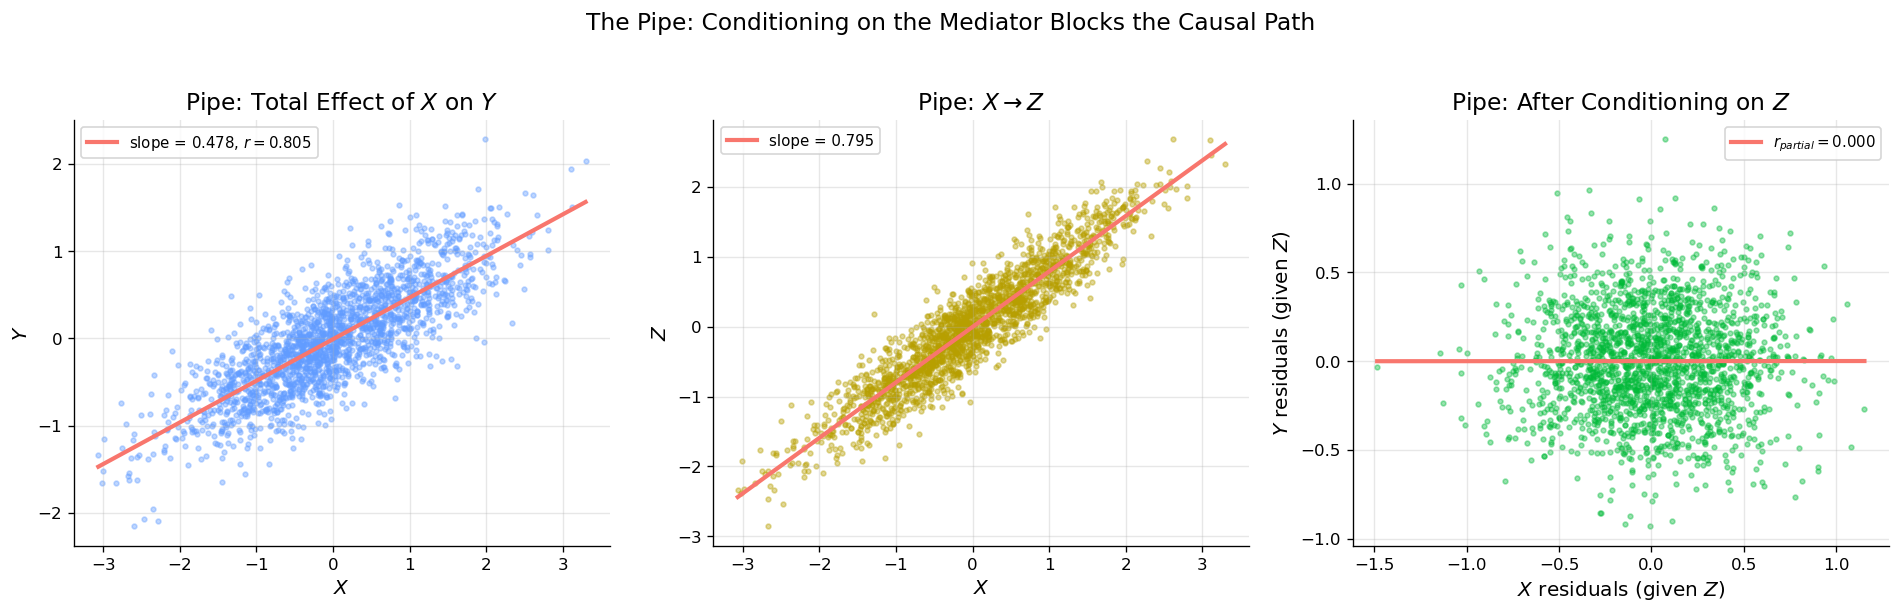

In [13]:
# ── Pipe: scatter plots ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: X vs Y (total effect)
axes[0].scatter(X_pipe, Y_pipe, s=8, alpha=0.4, color=PERIWINKLE)
m_p, b_p = np.polyfit(X_pipe, Y_pipe, 1)
xr = np.linspace(X_pipe.min(), X_pipe.max(), 100)
axes[0].plot(
    xr,
    m_p * xr + b_p,
    color=SALMON,
    lw=2.5,
    label=f"slope = {m_p:.3f}, $r = {r_marg_pipe:.3f}$",
)
axes[0].set_xlabel("$X$")
axes[0].set_ylabel("$Y$")
axes[0].set_title("Pipe: Total Effect of $X$ on $Y$")
axes[0].legend(fontsize=9)

# Middle: X -> Z (first link)
axes[1].scatter(X_pipe, Z_pipe, s=8, alpha=0.4, color=GOLD)
m_xz, b_xz = np.polyfit(X_pipe, Z_pipe, 1)
axes[1].plot(xr, m_xz * xr + b_xz, color=SALMON, lw=2.5, label=f"slope = {m_xz:.3f}")
axes[1].set_xlabel("$X$")
axes[1].set_ylabel("$Z$")
axes[1].set_title("Pipe: $X \\rightarrow Z$")
axes[1].legend(fontsize=9)

# Right: residuals (conditioning on Z blocks the path)
axes[2].scatter(res_x_pipe, res_y_pipe, s=8, alpha=0.4, color=EMERALD)
m_rp, b_rp = np.polyfit(res_x_pipe, res_y_pipe, 1)
xr2 = np.linspace(res_x_pipe.min(), res_x_pipe.max(), 100)
axes[2].plot(
    xr2,
    m_rp * xr2 + b_rp,
    color=SALMON,
    lw=2.5,
    label=f"$r_{{partial}} = {r_part_pipe:.3f}$",
)
axes[2].set_xlabel("$X$ residuals (given $Z$)")
axes[2].set_ylabel("$Y$ residuals (given $Z$)")
axes[2].set_title("Pipe: After Conditioning on $Z$")
axes[2].legend(fontsize=9)

plt.suptitle(
    "The Pipe: Conditioning on the Mediator Blocks the Causal Path", fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()

**Left panel:** The total effect of $X$ on $Y$ is clearly visible.  The slope ($\approx 0.48$) matches the product of the two path coefficients ($0.8 \times 0.6$).

**Middle panel:** The first link of the pipe, $X \rightarrow Z$, shows a strong causal relationship.

**Right panel:** After conditioning on $Z$, the residual scatter is a shapeless cloud — no association remains.  Conditioning on the mediator has blocked the only path from $X$ to $Y$.

**The lesson:** If you want the **total effect**, do not control for mediators.  Controlling for $Z$ in a pipe removes the very causal effect you are trying to measure.  Only condition on $Z$ if you specifically want the **direct effect** (and in a pure pipe, the direct effect is zero by construction).

---

## 4. The Collider (The Dangerous One)

### Definition

A **collider** is the structure $X \rightarrow Z \leftarrow Y$, where $Z$ is a **common effect** of both $X$ and $Y$.  The arrows *collide* at $Z$.

### The default: $X$ and $Y$ are independent

Unlike the fork and the pipe, the collider path $X \rightarrow Z \leftarrow Y$ is **blocked** by default.  The variables $X$ and $Y$ are marginally independent:

$$X \perp\!\!\!\perp Y$$

This is because the two arrows point *into* $Z$.  Information from $X$ flows into $Z$ and "stops" there; it cannot continue to $Y$ through the collider.  Similarly, information from $Y$ flows into $Z$ and stops.

### Conditioning on $Z$ opens the path (!)

Here is the counter-intuitive part.  If we **condition on** $Z$ (the collider), the path is **opened**, and a spurious association between $X$ and $Y$ is **created**:

$$X \not\!\perp\!\!\!\perp Y \mid Z \qquad \text{(conditional dependence in a collider)}$$

### Why does conditioning create an association?

Think of it this way.  Suppose $Z = X + Y + \varepsilon$.  If you know $Z$ and you learn that $X$ is large, then $Y$ must be small (to explain the fixed value of $Z$).  This is the **"explain-away" effect**: once you know the outcome $Z$, the two causes become negatively correlated because each "competes" to explain $Z$.

More formally: $P(Y \mid Z)$ depends on how much of $Z$ is "already explained" by $X$.  So conditioning on $Z$ makes $Y$ depend on $X$.

### Classic example: The Hollywood talent–attractiveness paradox

- $X$ = acting talent
- $Y$ = physical attractiveness
- $Z$ = Hollywood success (getting roles)

In the general population, talent and attractiveness are unrelated.  But Hollywood success depends on *both*.  Among successful actors (conditioning on $Z$ = "success"), those who are less attractive must compensate with greater talent, and vice versa.  This creates an apparent negative correlation between talent and attractiveness — but only within the selected group.

### Berkson's paradox

This phenomenon was first described in the medical literature by Joseph Berkson (1946).  He noticed that in **hospital studies**, diseases that are unrelated in the general population appeared correlated.  The explanation: being in the hospital (the collider) is caused by both diseases.  Among hospitalised patients, if a patient does not have disease $A$, they are more likely to have disease $B$ (otherwise, why are they in the hospital?).

### Simulation

**Data-generating process:**

$$X \sim \mathcal{N}(0, 1) \qquad Y \sim \mathcal{N}(0, 1) \qquad X \perp\!\!\!\perp Y$$
$$Z = 0.7\,X + 0.7\,Y + \varepsilon_Z, \qquad \varepsilon_Z \sim \mathcal{N}(0, 0.3^2)$$

$X$ and $Y$ are generated independently.  They are marginally uncorrelated.  But conditioning on $Z$ will create a **negative** association.

In [14]:
# ── Collider simulation ──
X_coll = rng.normal(0, 1, n)
Y_coll = rng.normal(0, 1, n)  # independent of X!
Z_coll = 0.7 * X_coll + 0.7 * Y_coll + rng.normal(0, 0.3, n)

# Marginal correlation (should be ~0)
r_marg_coll, p_marg_coll = stats.pearsonr(X_coll, Y_coll)
print(f"Marginal correlation r(X, Y) = {r_marg_coll:.4f}  (p = {p_marg_coll:.3f})")
print("X and Y are independent — as expected.")

# Partial correlation conditioning on Z (should be NEGATIVE)
r_part_coll, p_part_coll, res_x_coll, res_y_coll = partial_correlation(
    X_coll, Y_coll, Z_coll
)
print(f"\nPartial correlation r(X, Y | Z) = {r_part_coll:.4f}  (p = {p_part_coll:.2e})")
print("Conditioning on the collider Z CREATES a strong negative association!")
print("This is the explain-away effect.")

Marginal correlation r(X, Y) = -0.0274  (p = 0.221)
X and Y are independent — as expected.

Partial correlation r(X, Y | Z) = -0.8471  (p = 0.00e+00)
Conditioning on the collider Z CREATES a strong negative association!
This is the explain-away effect.


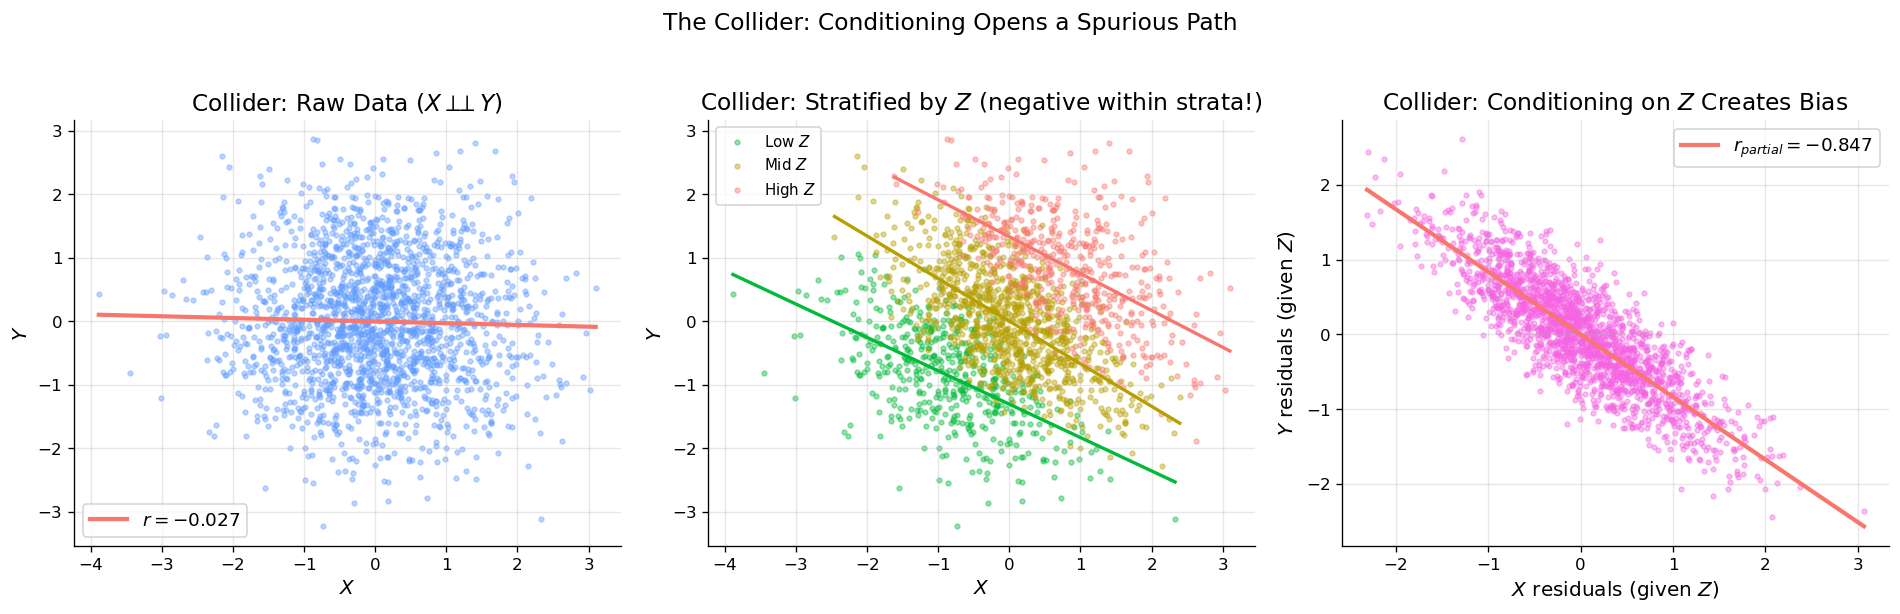

In [15]:
# ── Collider: scatter plots ──
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Left: raw scatter X vs Y (marginal — independent)
axes[0].scatter(X_coll, Y_coll, s=8, alpha=0.4, color=PERIWINKLE)
m_c, b_c = np.polyfit(X_coll, Y_coll, 1)
xr = np.linspace(X_coll.min(), X_coll.max(), 100)
axes[0].plot(xr, m_c * xr + b_c, color=SALMON, lw=2.5, label=f"$r = {r_marg_coll:.3f}$")
axes[0].set_xlabel("$X$")
axes[0].set_ylabel("$Y$")
axes[0].set_title("Collider: Raw Data ($X \\perp\\!\\!\\!\\perp Y$)")
axes[0].legend()

# Middle: stratified by Z (high Z only — "selecting" on the collider)
z_thresh = np.percentile(Z_coll, 75)
high_z = Z_coll >= z_thresh
low_z = Z_coll < np.percentile(Z_coll, 25)
mid_z = ~high_z & ~low_z

for mask, lbl, col in [
    (low_z, "Low $Z$", EMERALD),
    (mid_z, "Mid $Z$", GOLD),
    (high_z, "High $Z$", SALMON),
]:
    axes[1].scatter(X_coll[mask], Y_coll[mask], s=8, alpha=0.4, color=col, label=lbl)
    if mask.sum() > 2:
        m_s, b_s = np.polyfit(X_coll[mask], Y_coll[mask], 1)
        xr_s = np.linspace(X_coll[mask].min(), X_coll[mask].max(), 50)
        axes[1].plot(xr_s, m_s * xr_s + b_s, color=col, lw=2)
axes[1].set_xlabel("$X$")
axes[1].set_ylabel("$Y$")
axes[1].set_title("Collider: Stratified by $Z$ (negative within strata!)")
axes[1].legend(fontsize=9)

# Right: residuals (conditioning on Z)
axes[2].scatter(res_x_coll, res_y_coll, s=8, alpha=0.4, color=ORCHID)
m_rc, b_rc = np.polyfit(res_x_coll, res_y_coll, 1)
xr2 = np.linspace(res_x_coll.min(), res_x_coll.max(), 100)
axes[2].plot(
    xr2,
    m_rc * xr2 + b_rc,
    color=SALMON,
    lw=2.5,
    label=f"$r_{{partial}} = {r_part_coll:.3f}$",
)
axes[2].set_xlabel("$X$ residuals (given $Z$)")
axes[2].set_ylabel("$Y$ residuals (given $Z$)")
axes[2].set_title("Collider: Conditioning on $Z$ Creates Bias")
axes[2].legend()

plt.suptitle("The Collider: Conditioning Opens a Spurious Path", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Left panel:** $X$ and $Y$ are independent.  The regression line is flat and $r \approx 0$.

**Middle panel:** Within each stratum of $Z$, $X$ and $Y$ are **negatively** correlated.  Among observations with high $Z$, those with large $X$ tend to have smaller $Y$ (and vice versa), because both compete to explain the high $Z$ value.

**Right panel:** The partial correlation $r(X, Y \mid Z)$ is strongly negative.  Conditioning on the collider has manufactured a spurious association out of thin air.

**The lesson:** Never condition on a collider.  Doing so creates a bias that did not exist in the raw data.  The naive strategy of "control for everything" is dangerous precisely because some variables are colliders.

### A closer look: the explain-away effect

Let us visualise the explain-away effect more directly.  We select only observations where $Z$ is near a specific value and show that $X$ and $Y$ become negatively associated.

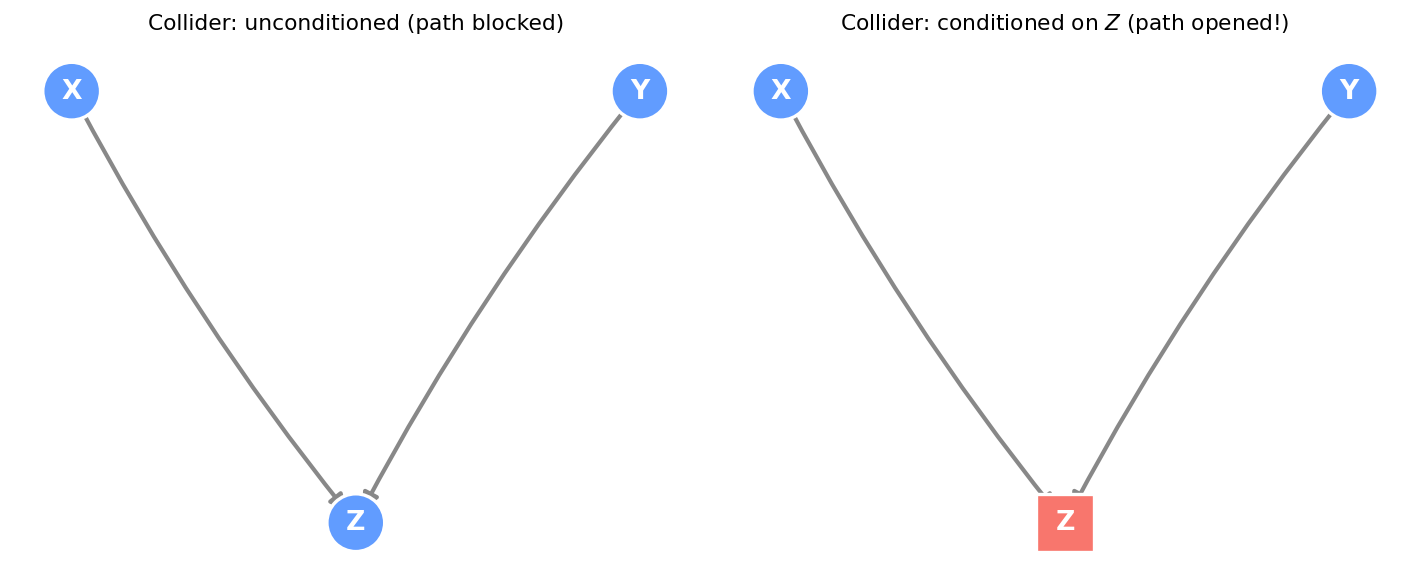

In [16]:
# ── Explain-away visualisation ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# DAGs
draw_dag(
    [("X", "Z"), ("Y", "Z")],
    {"X": (0, 1), "Z": (1, 0), "Y": (2, 1)},
    title="Collider: unconditioned (path blocked)",
    ax=axes[0],
)

draw_dag(
    [("X", "Z"), ("Y", "Z")],
    {"X": (0, 1), "Z": (1, 0), "Y": (2, 1)},
    title="Collider: conditioned on $Z$ (path opened!)",
    ax=axes[1],
    conditioned={"Z"},
)

plt.tight_layout()
plt.show()

---

## 5. Manim Animation: Data Flow Through Confounds

The following animation shows each of the three structures in sequence.  For each, small "data" dots flow along the edges of the DAG to show how association is transmitted.  We then show what happens when we condition on $Z$ — the path is either blocked (fork, pipe) or opened (collider).

In [4]:
from manim import *

cfg.apply_manim_config()

Manim Community v0.18.1

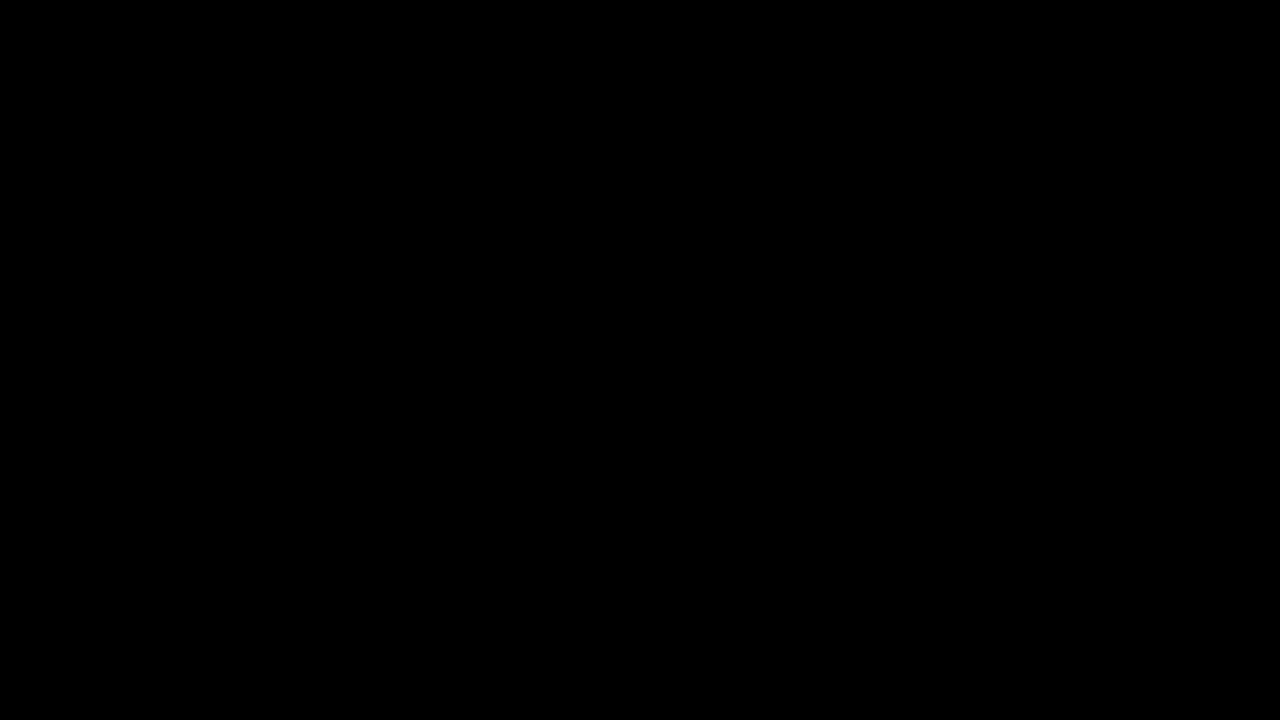

In [5]:
%%manim -qm -v WARNING ConfoundFlow

from amstats.manim_utils import C


class ConfoundFlow(Scene):
    """Animate data flow through Fork, Pipe, and Collider structures.

    For each structure:
      1. Show the DAG with nodes and directed edges.
      2. Unconditioned: gold dots flow along open paths.
      3. Conditioned on Z: Z turns salmon, paths are blocked or opened.
    """

    def construct(self):
        self.camera.background_color = BLACK

        # ── Utility functions ──
        def make_node(label, pos, color=C.PERIWINKLE):
            circ = Circle(
                radius=0.4,
                color=color,
                fill_opacity=0.85,
                stroke_color=WHITE,
                stroke_width=2,
            ).move_to(pos)
            txt = Text(label, font_size=28, color=WHITE, weight=BOLD).move_to(pos)
            return VGroup(circ, txt)

        def make_arrow(start, end, color=WHITE):
            return Arrow(
                start,
                end,
                color=color,
                stroke_width=3,
                buff=0.45,
                max_tip_length_to_length_ratio=0.15,
            )

        def flow_dots(start_pos, end_pos, n_dots=5, color=C.GOLD, run_time=1.5):
            """Create dots that flow from start to end position."""
            dots = VGroup(
                *[
                    Dot(radius=0.07, color=color, fill_opacity=0.9).move_to(start_pos)
                    for _ in range(n_dots)
                ]
            )
            anims = []
            for i, dot in enumerate(dots):
                delay = i * run_time / (n_dots + 1)
                anims.append(
                    Succession(
                        Wait(delay),
                        dot.animate(run_time=run_time * 0.5, rate_func=linear).move_to(
                            end_pos
                        ),
                        FadeOut(dot, run_time=0.15),
                    )
                )
            return dots, anims

        def make_block_cross(arrow, color=C.EMERALD):
            mid = arrow.get_center()
            l1 = Line(
                mid + UP * 0.2 + LEFT * 0.2,
                mid + DOWN * 0.2 + RIGHT * 0.2,
                color=color,
                stroke_width=5,
            )
            l2 = Line(
                mid + UP * 0.2 + RIGHT * 0.2,
                mid + DOWN * 0.2 + LEFT * 0.2,
                color=color,
                stroke_width=5,
            )
            return VGroup(l1, l2)

        def condition_node(node, color=C.SALMON):
            """Replace circle with a square to indicate conditioning."""
            sq = Square(
                side_length=0.85,
                color=color,
                fill_opacity=0.85,
                stroke_color=WHITE,
                stroke_width=2,
            )
            sq.move_to(node[0].get_center())
            return sq

        # ================================================================
        # SECTION 1: FORK  X <- Z -> Y
        # ================================================================
        title_fork = Text("Fork: Common Cause", font_size=32, color=C.LABEL).to_edge(
            UP, buff=0.3
        )
        self.play(Write(title_fork), run_time=0.6)

        # Positions
        z_pos = UP * 0.5
        x_pos = LEFT * 2.5 + DOWN * 1.5
        y_pos = RIGHT * 2.5 + DOWN * 1.5

        z_node = make_node("Z", z_pos)
        x_node = make_node("X", x_pos)
        y_node = make_node("Y", y_pos)

        arr_zx = make_arrow(z_pos, x_pos)
        arr_zy = make_arrow(z_pos, y_pos)

        fork_group = VGroup(z_node, x_node, y_node, arr_zx, arr_zy)
        self.play(
            FadeIn(x_node),
            FadeIn(y_node),
            FadeIn(z_node),
            Create(arr_zx),
            Create(arr_zy),
            run_time=1.0,
        )

        # Unconditioned: data flows Z->X and Z->Y (association exists)
        uc_label = Text(
            "Unconditioned: X and Y correlated", font_size=22, color=C.GOLD
        ).to_edge(DOWN, buff=0.4)
        self.play(Write(uc_label), run_time=0.4)

        # Fork section:
        dots1, anims1 = flow_dots(arr_zx.get_start(), arr_zx.get_end())
        dots2, anims2 = flow_dots(arr_zy.get_start(), arr_zy.get_end())
        self.add(*dots1, *dots2)
        self.play(*anims1, *anims2, run_time=2.0)
        self.wait(0.5)

        # Conditioned on Z: path blocked
        z_sq = condition_node(z_node)
        cond_label = Text(
            "Condition on Z: path blocked", font_size=22, color=C.EMERALD
        ).to_edge(DOWN, buff=0.4)
        block1 = make_block_cross(arr_zx)
        block2 = make_block_cross(arr_zy)

        self.play(
            Transform(z_node[0], z_sq),
            z_node[0].animate.set_color(C.SALMON),
            Transform(uc_label, cond_label),
            FadeIn(block1),
            FadeIn(block2),
            run_time=1.0,
        )
        self.wait(1.5)

        self.play(*[FadeOut(m) for m in self.mobjects], run_time=0.6)

        # ================================================================
        # SECTION 2: PIPE  X -> Z -> Y
        # ================================================================
        title_pipe = Text("Pipe: Mediator", font_size=32, color=C.LABEL).to_edge(
            UP, buff=0.3
        )
        self.play(Write(title_pipe), run_time=0.6)

        x_pos2 = LEFT * 3 + ORIGIN
        z_pos2 = ORIGIN
        y_pos2 = RIGHT * 3 + ORIGIN

        x_node2 = make_node("X", x_pos2)
        z_node2 = make_node("Z", z_pos2)
        y_node2 = make_node("Y", y_pos2)

        arr_xz = make_arrow(x_pos2, z_pos2)
        arr_zy2 = make_arrow(z_pos2, y_pos2)

        self.play(
            FadeIn(x_node2),
            FadeIn(z_node2),
            FadeIn(y_node2),
            Create(arr_xz),
            Create(arr_zy2),
            run_time=1.0,
        )

        # Unconditioned: data flows X->Z->Y
        uc_label2 = Text(
            "Unconditioned: causal effect flows X to Y", font_size=22, color=C.GOLD
        ).to_edge(DOWN, buff=0.4)
        self.play(Write(uc_label2), run_time=0.4)

        # Pipe section:
        dots3, anims3 = flow_dots(arr_xz.get_start(), arr_xz.get_end())
        dots4, anims4 = flow_dots(arr_zy2.get_start(), arr_zy2.get_end())
        self.add(*dots3, *dots4)
        self.play(*anims3, run_time=1.5)
        self.play(*anims4, run_time=1.5)
        self.wait(0.3)

        # Conditioned on Z: path blocked
        z_sq2 = condition_node(z_node2)
        cond_label2 = Text(
            "Condition on Z: causal path blocked", font_size=22, color=C.EMERALD
        ).to_edge(DOWN, buff=0.4)
        block3 = make_block_cross(arr_xz)
        block4 = make_block_cross(arr_zy2)

        self.play(
            Transform(z_node2[0], z_sq2),
            z_node2[0].animate.set_color(C.SALMON),
            Transform(uc_label2, cond_label2),
            FadeIn(block3),
            FadeIn(block4),
            run_time=1.0,
        )
        self.wait(1.5)

        self.play(*[FadeOut(m) for m in self.mobjects], run_time=0.6)

        # ================================================================
        # SECTION 3: COLLIDER  X -> Z <- Y
        # ================================================================
        title_coll = Text(
            "Collider: Common Effect", font_size=32, color=C.LABEL
        ).to_edge(UP, buff=0.3)
        self.play(Write(title_coll), run_time=0.6)

        x_pos3 = LEFT * 2.5 + UP * 1.5
        y_pos3 = RIGHT * 2.5 + UP * 1.5
        z_pos3 = DOWN * 0.5

        x_node3 = make_node("X", x_pos3)
        y_node3 = make_node("Y", y_pos3)
        z_node3 = make_node("Z", z_pos3)

        arr_xz3 = make_arrow(x_pos3, z_pos3)
        arr_yz3 = make_arrow(y_pos3, z_pos3)

        self.play(
            FadeIn(x_node3),
            FadeIn(y_node3),
            FadeIn(z_node3),
            Create(arr_xz3),
            Create(arr_yz3),
            run_time=1.0,
        )

        # Unconditioned: path blocked (no flow between X and Y)
        uc_label3 = Text(
            "Unconditioned: X and Y are independent", font_size=22, color=C.GOLD
        ).to_edge(DOWN, buff=0.4)
        self.play(Write(uc_label3), run_time=0.4)

        indep_text = Text("X \u22a5 Y", font_size=36, color=C.EMERALD)
        indep_text.move_to(ORIGIN + UP * 0.2)
        self.play(Write(indep_text), run_time=0.8)
        self.wait(1.0)
        self.play(FadeOut(indep_text), run_time=0.3)

        # Conditioned on Z: path OPENED — spurious association created
        z_sq3 = condition_node(z_node3)
        cond_label3 = Text(
            "Condition on Z: spurious association CREATED!",
            font_size=22,
            color=C.SALMON,
        ).to_edge(DOWN, buff=0.4)

        # Draw a dashed spurious-association line between X and Y
        spurious_line = DashedLine(
            x_pos3, y_pos3, color=C.SALMON, stroke_width=3, dash_length=0.15
        )
        spurious_label = Text("Spurious!", font_size=24, color=C.SALMON)
        spurious_label.next_to(spurious_line, UP, buff=0.15)

        self.play(
            Transform(z_node3[0], z_sq3),
            z_node3[0].animate.set_color(C.SALMON),
            Transform(uc_label3, cond_label3),
            run_time=0.8,
        )

        # Dots flow along the spurious path
        # Collider spurious line:
        # Collider spurious line:
        dots_sp, anims_sp = flow_dots(
            x_pos3, y_pos3, n_dots=8, color=C.SALMON, run_time=2.0
        )

        self.play(
            Create(spurious_line),
            Write(spurious_label),
            run_time=0.6,
        )
        self.add(*dots_sp)
        self.play(*anims_sp, run_time=2.0)
        self.wait(1.0)

        # ── Final summary ──
        self.play(*[FadeOut(m) for m in self.mobjects], run_time=0.5)

        summary = (
            VGroup(
                Text("Summary", font_size=34, color=C.LABEL),
                Text(
                    "Fork:     condition on Z  \u2192  removes spurious assoc.",
                    font_size=22,
                    color=C.EMERALD,
                ),
                Text(
                    "Pipe:     condition on Z  \u2192  blocks causal path",
                    font_size=22,
                    color=C.EMERALD,
                ),
                Text(
                    "Collider: condition on Z  \u2192  CREATES spurious assoc.",
                    font_size=22,
                    color=C.SALMON,
                ),
            )
            .arrange(DOWN, aligned_edge=LEFT, buff=0.4)
            .move_to(ORIGIN)
        )

        self.play(
            LaggedStart(*[Write(s) for s in summary], lag_ratio=0.4),
            run_time=3.0,
        )
        self.wait(2.5)

The animation illustrates the core logic:

- **Fork and Pipe:** Conditioning on $Z$ (turning it from a circle to a square) *blocks* the flow of association.  The green X marks show paths being closed.
- **Collider:** Conditioning on $Z$ *opens* a path that was previously closed, creating a spurious dashed-line association between $X$ and $Y$ (shown in salmon).

This visual metaphor — data "flowing" through DAG edges — is a powerful way to build intuition about d-separation and conditional independence.

---

## 6. Simpson's Paradox as a Consequence of the Fork

**Simpson's Paradox** is the phenomenon where a trend that appears in the aggregate data **reverses** when the data are split into subgroups.  It is a direct consequence of confounding — specifically, the fork structure.

### Setup

Imagine we are studying the effect of a treatment $X$ (0 = control, 1 = treated) on recovery $Y$ (continuous outcome), but there is a confounding variable $Z$ (two groups, $A$ and $B$) that affects both treatment assignment and outcome.

The DAG is a fork: $X \leftarrow Z \rightarrow Y$, and there may also be a direct effect $X \rightarrow Y$.

### Simulation

We construct data where:
- Group $A$ (high $Z$) patients are sicker and more likely to receive treatment.
- Treatment has a *positive* causal effect within each group.
- But the aggregate data show a *negative* association because treated patients tend to be sicker.

In [7]:
# ── Simpson's Paradox simulation ──
rng_s = np.random.default_rng(123)
n_simp = 500

# Group assignment (confounder)
group = rng_s.choice(["A", "B"], size=n_simp, p=[0.5, 0.5])
is_A = (group == "A").astype(float)

# Treatment assignment depends on group (confounding!)
# Group A (sicker) more likely to get treatment
p_treat = np.where(is_A, 0.8, 0.2)  # 80% treated in A, 20% in B
treatment = rng_s.binomial(1, p_treat)

# Outcome: treatment HELPS (+3), but group A is sicker (-6 baseline shift)
baseline = np.where(is_A, 50.0, 62.0)  # Group A sicker
treatment_effect = 3.0  # true positive causal effect
noise = rng_s.normal(0, 3, n_simp)
outcome = baseline + treatment_effect * treatment + noise

# Aggregate statistics
mean_treated = outcome[treatment == 1].mean()
mean_control = outcome[treatment == 0].mean()
print("=== Aggregate (ignoring group) ===")
print(f"  Treated mean:  {mean_treated:.2f}")
print(f"  Control mean:  {mean_control:.2f}")
print(f"  Difference:    {mean_treated - mean_control:.2f}  (treatment looks HARMFUL!)")

# Stratified statistics
print("\n=== Stratified by Group ===")
for g in ["A", "B"]:
    mask_g = group == g
    mt = outcome[mask_g & (treatment == 1)].mean()
    mc = outcome[mask_g & (treatment == 0)].mean()
    print(
        f"  Group {g}: treated = {mt:.2f}, control = {mc:.2f}, "
        f"diff = {mt - mc:+.2f}  (treatment HELPS)"
    )

print(f"\nTrue treatment effect: +{treatment_effect:.1f}")
print("Simpson's Paradox: the aggregate trend REVERSES within subgroups!")

=== Aggregate (ignoring group) ===
  Treated mean:  55.01
  Control mean:  59.76
  Difference:    -4.75  (treatment looks HARMFUL!)

=== Stratified by Group ===
  Group A: treated = 52.81, control = 49.93, diff = +2.89  (treatment HELPS)
  Group B: treated = 65.71, control = 62.07, diff = +3.65  (treatment HELPS)

True treatment effect: +3.0
Simpson's Paradox: the aggregate trend REVERSES within subgroups!


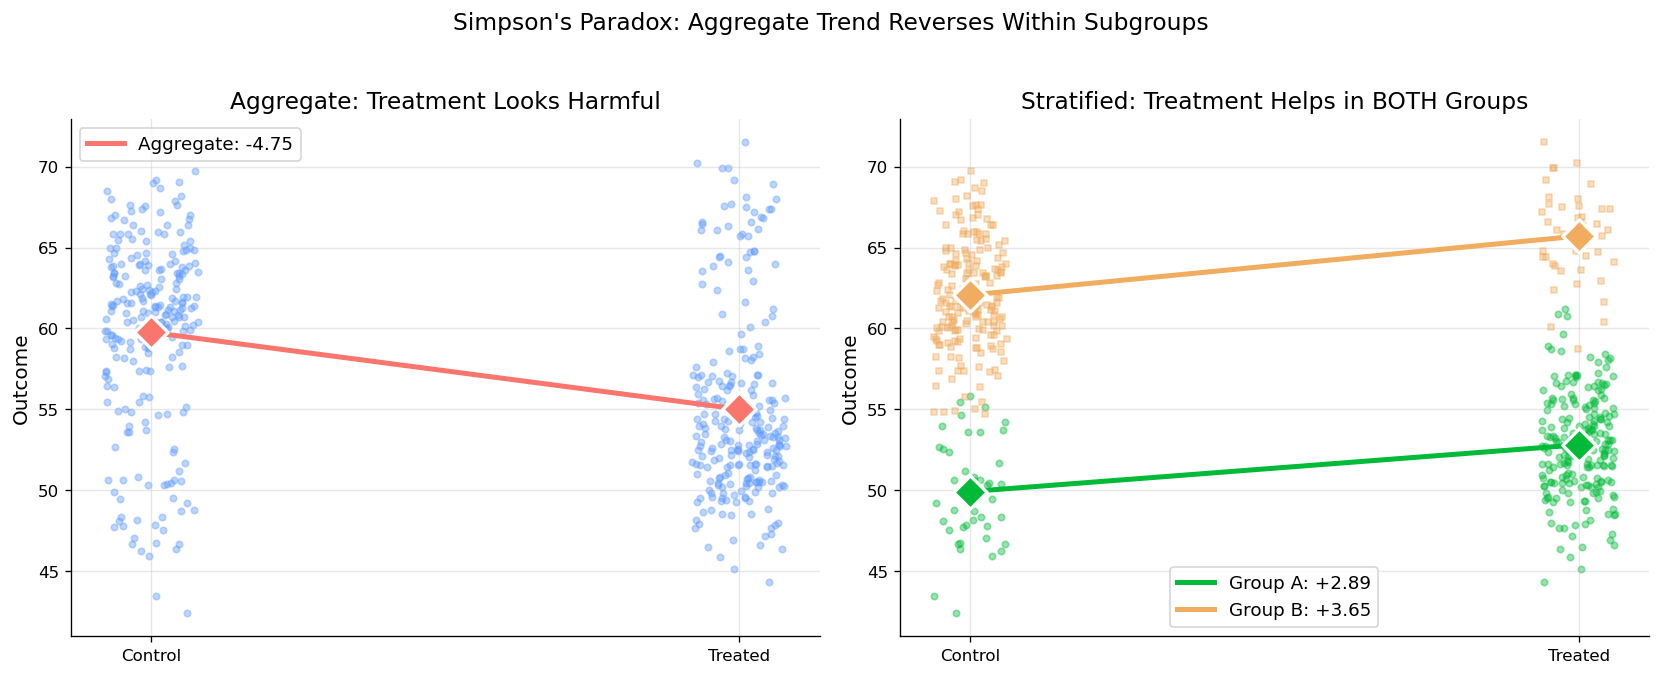

In [10]:
# ── Simpson's Paradox: visualisation ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: Aggregate scatter with regression line
jitter_x = treatment + rng_s.uniform(-0.08, 0.08, n_simp)
axes[0].scatter(jitter_x, outcome, s=15, alpha=0.4, color=str(PERIWINKLE))

# Aggregate means
axes[0].scatter(
    [0, 1],
    [mean_control, mean_treated],
    s=200,
    color=SALMON,
    zorder=5,
    edgecolors="white",
    linewidths=2,
    marker="D",
)
axes[0].plot(
    [0, 1],
    [mean_control, mean_treated],
    color=SALMON,
    lw=3,
    label=f"Aggregate: {mean_treated - mean_control:+.2f}",
)
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(["Control", "Treated"])
axes[0].set_ylabel("Outcome")
axes[0].set_title("Aggregate: Treatment Looks Harmful")
axes[0].legend(fontsize=11)

# Right: Stratified by group
for g, col, marker in [("A", str(EMERALD), "o"), ("B", str(GOLD), "s")]:
    mask_g = group == g
    jit = treatment[mask_g] + rng_s.uniform(-0.06, 0.06, mask_g.sum())
    axes[1].scatter(jit, outcome[mask_g], s=15, alpha=0.4, color=col, marker=marker)

    mt = outcome[mask_g & (treatment == 1)].mean()
    mc = outcome[mask_g & (treatment == 0)].mean()
    axes[1].scatter(
        [0, 1],
        [mc, mt],
        s=200,
        color=col,
        zorder=5,
        edgecolors="white",
        linewidths=2,
        marker="D",
    )
    axes[1].plot([0, 1], [mc, mt], color=col, lw=3, label=f"Group {g}: {mt - mc:+.2f}")

axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(["Control", "Treated"])
axes[1].set_ylabel("Outcome")
axes[1].set_title("Stratified: Treatment Helps in BOTH Groups")
axes[1].legend(fontsize=11)

plt.suptitle(
    "Simpson's Paradox: Aggregate Trend Reverses Within Subgroups", fontsize=14, y=1.02
)
plt.tight_layout()
plt.show()

**Left panel:** In the aggregate data, the treated group has a *lower* mean outcome than the control group.  Naively, this suggests the treatment is harmful.

**Right panel:** Within each group, the treated patients have a *higher* mean outcome.  The treatment is genuinely helpful, with an effect of approximately $+3$ units in both groups.

### Why does this happen?

Group $A$ patients are sicker (lower baseline outcome) and are more likely to receive treatment (80% vs. 20%).  This creates a confounding path:

$$\text{Treatment} \leftarrow \text{Group (severity)} \rightarrow \text{Outcome}$$

The aggregate comparison mixes together two effects:
1. The treatment effect (+3, beneficial)
2. The selection effect (sicker patients are more likely to be treated, making the treated group look worse)

Because the selection effect is larger than the treatment effect, the aggregate trend reverses.  **Stratifying by group** (conditioning on the confounder) reveals the true causal effect.

Simpson's Paradox is not a mathematical curiosity — it appears routinely in observational studies.  The solution is always the same: identify the confounders using a DAG and condition on them appropriately.

---

## 7. Summary Table

| Structure                    | DAG                             | Marginal $X$–$Y$      | Conditioning on $Z$              | Implication                                                   |
|------------------------------|---------------------------------|-----------------------|----------------------------------|---------------------------------------------------------------|
| **Fork** (common cause)      | $X \leftarrow Z \rightarrow Y$  | Correlated (spurious) | Removes association              | **Control for confounders** to remove bias                    |
| **Pipe** (mediator)          | $X \rightarrow Z \rightarrow Y$ | Correlated (causal)   | Blocks causal path               | **Do not control for mediators** if you want the total effect |
| **Collider** (common effect) | $X \rightarrow Z \leftarrow Y$  | Independent           | **Creates** spurious association | **Do not control for colliders** — it introduces bias         |

### The key principle

Conditioning on a variable can do one of two things:

1. **Close** an open path (fork or pipe) — this *removes* association.
2. **Open** a closed path (collider) — this *creates* association.

The correct adjustment strategy depends entirely on the causal structure.  There is no universal rule like "control for everything."  You must know the DAG.

### Mnemonics

- **Fork:** The common cause *forks* into two effects.  Block it to remove the spurious link.
- **Pipe:** Information *pipes* through the mediator.  Blocking the pipe stops the flow.
- **Collider:** Two arrows *collide* at one node.  Conditioning on the collision site opens a "secret passage" between the causes.

### All three structures at a glance

The following figure summarises the three structures with their conditioning behaviour.

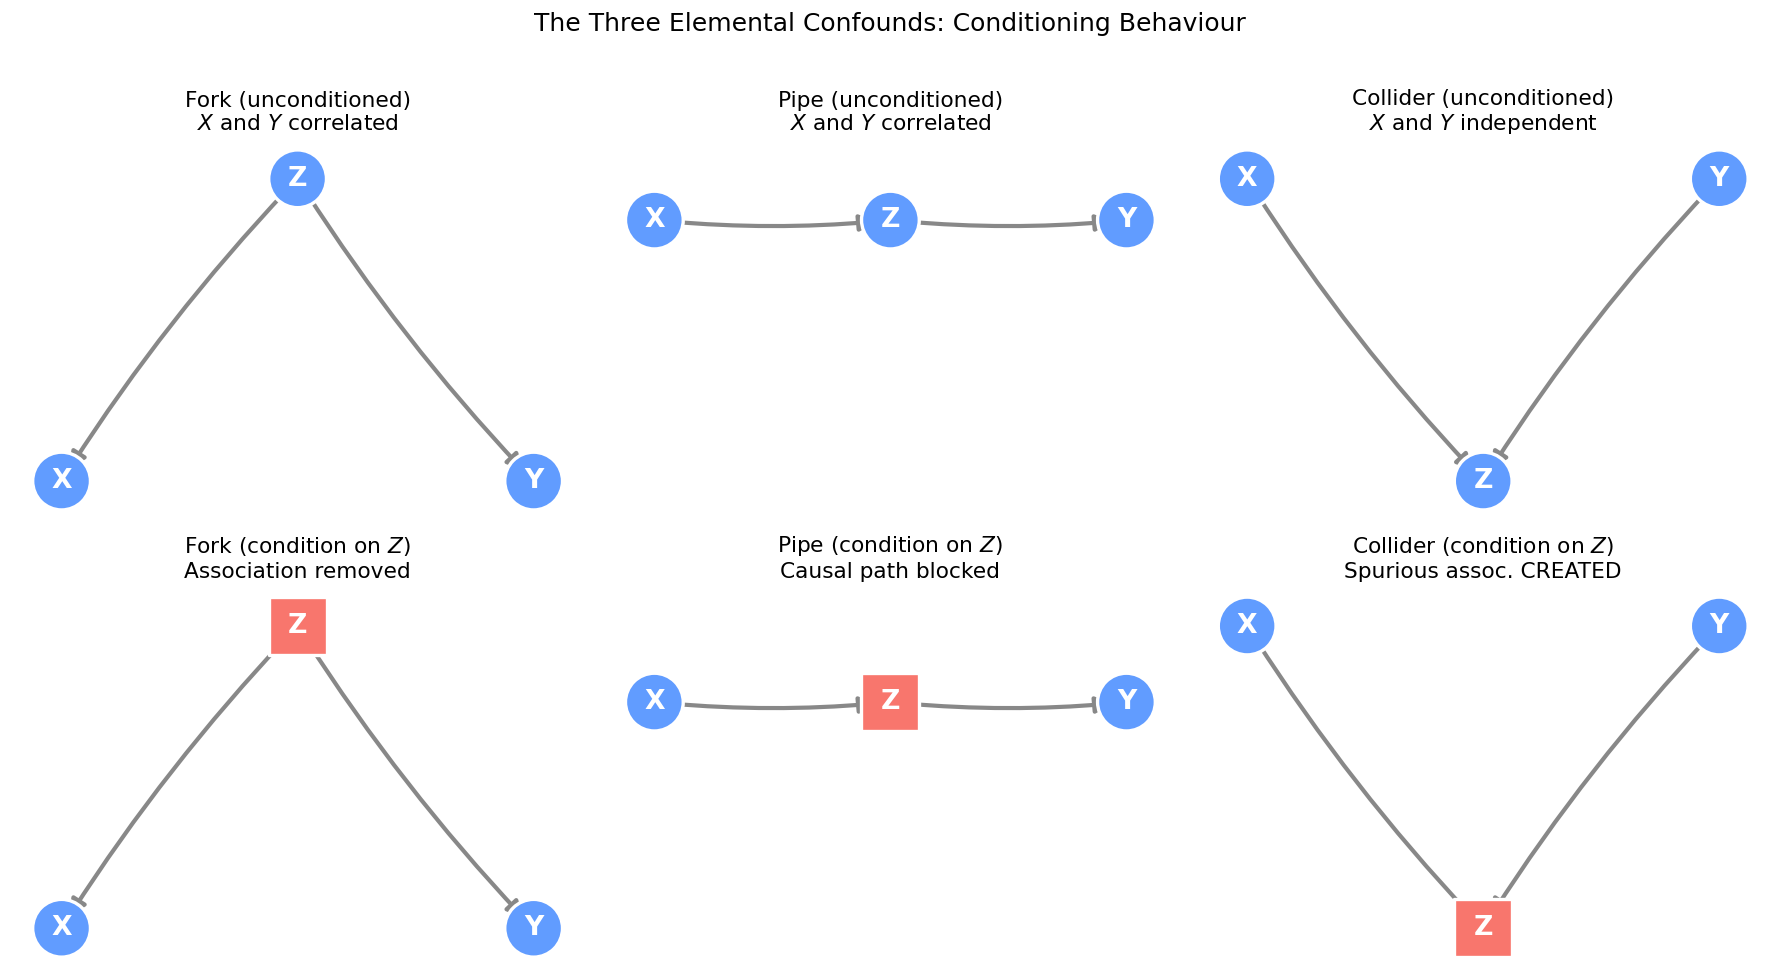

In [11]:
# ── Summary figure: all three structures, unconditioned and conditioned ──
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Row 0: unconditioned
draw_dag(
    [("Z", "X"), ("Z", "Y")],
    {"X": (0, 0), "Z": (1, 1), "Y": (2, 0)},
    title="Fork (unconditioned)\n$X$ and $Y$ correlated",
    ax=axes[0, 0],
)

draw_dag(
    [("X", "Z"), ("Z", "Y")],
    {"X": (0, 0), "Z": (1, 0), "Y": (2, 0)},
    title="Pipe (unconditioned)\n$X$ and $Y$ correlated",
    ax=axes[0, 1],
)

draw_dag(
    [("X", "Z"), ("Y", "Z")],
    {"X": (0, 1), "Z": (1, 0), "Y": (2, 1)},
    title="Collider (unconditioned)\n$X$ and $Y$ independent",
    ax=axes[0, 2],
)

# Row 1: conditioned on Z
draw_dag(
    [("Z", "X"), ("Z", "Y")],
    {"X": (0, 0), "Z": (1, 1), "Y": (2, 0)},
    title="Fork (condition on $Z$)\nAssociation removed",
    ax=axes[1, 0],
    conditioned={"Z"},
)

draw_dag(
    [("X", "Z"), ("Z", "Y")],
    {"X": (0, 0), "Z": (1, 0), "Y": (2, 0)},
    title="Pipe (condition on $Z$)\nCausal path blocked",
    ax=axes[1, 1],
    conditioned={"Z"},
)

draw_dag(
    [("X", "Z"), ("Y", "Z")],
    {"X": (0, 1), "Z": (1, 0), "Y": (2, 1)},
    title="Collider (condition on $Z$)\nSpurious assoc. CREATED",
    ax=axes[1, 2],
    conditioned={"Z"},
)

plt.suptitle(
    "The Three Elemental Confounds: Conditioning Behaviour", fontsize=15, y=1.01
)
plt.tight_layout()
plt.show()

---

## 8. Exercises

**Exercise 1 (Identifying structures).** For each of the following scenarios, draw the DAG, identify the elemental structure(s), and state whether you should condition on $Z$.

(a) You want to know if smoking ($X$) causes lung cancer ($Y$).  A genetic factor ($Z$) predisposes people to both smoking and lung cancer.  
(b) You want to know if a drug ($X$) lowers blood pressure ($Y$).  The drug works by relaxing blood vessels ($Z$).  
(c) You want to know if exercise ($X$) is correlated with diet quality ($Y$).  Both exercise and diet affect BMI ($Z$).

**Exercise 2 (Collider simulation).** Modify the collider simulation so that $Z = X \cdot Y + \varepsilon_Z$ (an interaction rather than a sum).  Does conditioning on $Z$ still create a spurious association?  Plot the results and compute the partial correlation.  *Hint:* The collider effect does not depend on the functional form; it depends only on the DAG structure.

**Exercise 3 (Berkson's paradox with hospital data).** Simulate a Berkson's paradox scenario:
- Disease A: $X \sim \text{Bernoulli}(0.1)$
- Disease B: $Y \sim \text{Bernoulli}(0.1)$, independent of $X$
- Hospitalisation: $Z = 1$ if $X = 1$ or $Y = 1$ or $U < 0.05$ (random hospitalisation), otherwise $Z = 0$

Compute $r(X, Y)$ in the general population vs. $r(X, Y \mid Z = 1)$ among hospitalised patients.  Show that the two diseases appear negatively correlated in the hospital sample.

**Exercise 4 (Simpson's Paradox with real-world framing).** The University of California, Berkeley was sued for sex discrimination in graduate admissions in 1973.  The aggregate admission rate was higher for men than women.  But within most departments, women were admitted at equal or higher rates.

Simulate a version of this scenario:
- Two departments: Easy (80% admission rate) and Hard (30% admission rate)
- Women disproportionately apply to the Hard department
- Within each department, admission rates are equal across genders

Show that the aggregate admission rate is lower for women, even though there is no gender bias in admissions.  Identify the fork structure and the confounder.

**Exercise 5 (Mixed structure).** Consider the DAG: $A \rightarrow B \rightarrow C \leftarrow D$.  
(a) Is the path $A - B - C - D$ open or closed?  
(b) What happens if you condition on $C$?  
(c) Simulate data from this DAG (choose your own coefficients) and verify your answers empirically using partial correlations.

---

## Key Takeaways

1. **Every DAG is built from three elemental structures** — fork, pipe, and collider.  Understanding these three patterns is sufficient to reason about conditional independence in arbitrarily complex causal models.

2. **The Fork** ($X \leftarrow Z \rightarrow Y$): A common cause creates a spurious correlation.  **Solution:** condition on $Z$ to remove the confounding.

3. **The Pipe** ($X \rightarrow Z \rightarrow Y$): A mediator transmits the causal effect.  **Danger:** conditioning on $Z$ blocks the causal path.  Only do this if you want the direct effect, not the total effect.

4. **The Collider** ($X \rightarrow Z \leftarrow Y$): A common effect.  $X$ and $Y$ are independent by default, but **conditioning on $Z$ creates a spurious association**.  This is the most counter-intuitive and commonly violated rule.

5. **"Control for everything" is wrong.**  Whether to condition on a variable depends on its role in the DAG.  Blindly adding controls can introduce collider bias or block causal paths.

6. **Simpson's Paradox** is a direct consequence of confounding (fork structure).  The solution is to identify and adjust for the confounder, which requires knowing the causal DAG.

7. **You need the DAG.**  Statistical data alone cannot tell you whether a variable is a confounder, mediator, or collider.  Causal reasoning requires causal assumptions, which are encoded in the DAG.

**Next:** [03_good_bad_controls.ipynb](03_good_bad_controls.ipynb) — using d-separation and the backdoor criterion to determine which variables to condition on in more complex DAGs.

In [12]:
cfg.save_gifs(clean=True)

  ✓ media/gifs/ConfoundFlow@2026-03-20@01-08-04.gif
  ✓ media/gifs/DSeparation@2026-03-20@00-51-58.gif
  ✓ media/gifs/ConfoundFlow_ManimCE_v0.18.1.gif
  Cleaned up local temp render files (kept media/jupyter/).
